In [56]:
# import h5py
# import numpy as np

# # Getting the data
# path = "/home/arpit/test_projects/mimicgen/datasets/generated_data_mimicgen_format/core_datasets_og/r1_dishes_away_ablation_only_soft/demo_src_r1_dishes_away_task_D0/demo.hdf5"
# f = h5py.File(path, "r")
# x, y = [], []
# for demo in f["data"].keys():
#     x.append(np.array(f[f"data/{demo}/datagen_info/object_poses/plate_601"])[0, 0, 3])
#     y.append(np.array(f[f"data/{demo}/datagen_info/object_poses/plate_601"])[0, 1, 3])
# x = np.array(x)
# y = np.array(y)

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# fig_width = 1280 / 100  # = 12.8 inches
# fig_height = 720 / 100  # = 7.2 inches

# # # Example: replace with your actual data
# # x = np.random.normal(6.7, 0.8, 100)
# # y = np.random.normal(-0.5, 1.0, 100)

# # Create the plot
# plt.figure(figsize=(12.8, 7.2), dpi=100)
# sns.kdeplot(x=x, y=y, fill=True, cmap="Blues", bw_adjust=0.3, levels=50, thresh=0.05)
# # plt.scatter(x, y, c='orange', s=20)

# # Set plot limits and labels
# plt.xlim(6.7 - 3.5, 6.7 + 3.5)
# plt.ylim(-0.5 - 2.25, -0.5 + 2.25)
# plt.gca().invert_xaxis()
# plt.gca().invert_yaxis()
# plt.xlabel("x (m)")
# plt.ylabel("y (m)")
# plt.tight_layout()
# plt.show()

In [1]:
import json
import h5py
import omnigibson as og
import torch as th
th.set_printoptions(precision=3, sci_mode=False)
import numpy as np
np.set_printoptions(precision=3, suppress=True)
from omnigibson.macros import create_module_macros
from omnigibson.action_primitives.starter_semantic_action_primitives import StarterSemanticActionPrimitives
import omnigibson.utils.transform_utils as T
from scipy.spatial.transform import Rotation as R
import omnigibson.lazy as lazy
from omnigibson import object_states
from omnigibson.objects.primitive_object import PrimitiveObject
from omnigibson.objects.dataset_object import DatasetObject

from omnigibson.macros import gm
from PIL import Image
import os
import matplotlib.pyplot as plt

image_folder = "/scr/chengshu/Downloads/images"
# image_folder = "/vision/u/chengshu/figure_images
data_folder = "/mnt/chengshu"
# data_folder = "/vision/u/chengshu

gm.DATASET_PATH = "/cvgl2/u/chengshu/OmniGibson/omnigibson/data/og_dataset"

seed = 0
np.random.seed(seed)
th.manual_seed(seed)

# Load the scene from the hdf5 file
with h5py.File("/cvgl2/u/chengshu/mimicgen/datasets/source_og/r1_tidy_table.hdf5", "r") as f:
    config = f["data"].attrs["config"]

config = json.loads(config)

# Custom changes
config["scene"]["load_room_instances"] = ["kitchen_0", "dining_room_0", "entryway_0", "living_room_0"]
config["robots"][0]["position"] = [0.0, 0.0, 0.0]
config["robots"][0]["orientation"] = [0.0, 0.0, 0.0, 1.0]

env = og.Environment(configs=config)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


[INFO] [omnigibson.simulator] ----- Starting OmniGibson. This will take 10-30 seconds... -----


Starting kit application with the following args:  ['/scr/chengshu/anaconda3/envs/omnigibson-test/lib/python3.10/site-packages/isaacsim/exts/isaacsim.simulation_app/isaacsim/simulation_app/simulation_app.py', '/scr/chengshu/anaconda3/envs/omnigibson-test/lib/python3.10/site-packages/isaacsim/apps/omnigibson_4_5_0.kit', '--/app/tokens/exe-path=/scr/chengshu/anaconda3/envs/omnigibson-test/lib/python3.10/site-packages/omni', '--/persistent/app/viewport/displayOptions=3094', '--/rtx/materialDb/syncLoads=True', '--/rtx/hydra/materialSyncLoads=True', '--/omni.kit.plugin/syncUsdLoads=True', '--/app/renderer/resolution/width=1280', '--/app/renderer/resolution/height=720', '--/app/window/width=1440', '--/app/window/height=900', '--/renderer/multiGpu/enabled=False', '--/app/fastShutdown=False', '--/app/installSignalHandlers=0', '--ext-folder', '/scr/chengshu/anaconda3/envs/omnigibson-test/lib/python3.10/site-packages/isaacsim/exts', '--ext-folder', '/scr/chengshu/anaconda3/envs/omnigibson-test/l

[DEBUG] [AutoNode] Defining data type 'any' as 'Any'
[DEBUG] [AutoNode] Defining data type 'bool' as 'Bool' and array 'BoolArray
[DEBUG] [AutoNode] Defining data type 'bundle' as 'Bundle'
[DEBUG] [AutoNode] Defining data type 'colord[3]' as 'Color3d' and array 'Color3dArray
[DEBUG] [AutoNode] Defining data type 'colorf[3]' as 'Color3f' and array 'Color3fArray
[DEBUG] [AutoNode] Defining data type 'colorh[3]' as 'Color3h' and array 'Color3hArray
[DEBUG] [AutoNode] Defining data type 'colord[4]' as 'Color4d' and array 'Color4dArray
[DEBUG] [AutoNode] Defining data type 'colorf[4]' as 'Color4f' and array 'Color4fArray
[DEBUG] [AutoNode] Defining data type 'colorh[4]' as 'Color4h' and array 'Color4hArray
[DEBUG] [AutoNode] Defining data type 'double' as 'Double' and array 'DoubleArray
[DEBUG] [AutoNode] Defining data type 'double[2]' as 'Double2' and array 'Double2Array
[DEBUG] [AutoNode] Defining data type 'double[3]' as 'Double3' and array 'Double3Array
[DEBUG] [AutoNode] Defining data t

xt: omni.usd.schema.metrics.assembler-106.5.0] startup
[8.095s] [ext: omni.usd.schema.physx-106.5.7] startup
[8.132s] [ext: omni.usd.schema.audio-0.0.0] startup
[8.136s] [ext: omni.usd.schema.geospatial-0.0.0] startup
[8.140s] [ext: omni.usd.schema.semantics-0.0.0] startup
[8.144s] [ext: omni.usd.schema.forcefield-106.5.7] startup
[8.151s] [ext: omni.usd.schema.omnigraph-1.0.0] startup
[8.160s] [ext: isaacsim.robot.schema-3.1.2] startup
[8.170s] [ext: omni.usd.schema.omniscripting-1.0.0] startup
[8.177s] [ext: omni.usd.schema.isaac-3.0.2] startup
[8.177s] [ext: omni.usd.schema.anim-0.0.0] startup
[8.206s] [ext: omni.usd.schema.flow-107.0.0] startup
[8.206s] [ext: omni.graph.exec-0.9.4] startup
[8.207s] [ext: omni.kit.usd_undo-0.1.8] startup
[8.207s] [ext: omni.kit.actions.core-1.0.0] startup
[8.210s] [ext: omni.kit.exec.core-0.13.4] startup
[8.212s] [ext: omni.usd_resolver-1.0.0] startup
[8.218s] [ext: omni.kit.commands-1.4.9] startup
[8.221s] [ext: omni.activity.core-1.0.1] startup
[8

...

2025-05-16 05:32:28 [68,546ms] [Warning] [omnigibson.objects.stateful_object] State AttachedTo is incompatible with obj mirror_ndvgah_0. Reason: LinkBasedStateMixin AttachedTo requires meta link with type attachment for obj mirror_ndvgah_0 but none was found! To get valid compatible object models, please use omnigibson.utils.asset_utils.get_all_object_category_models_with_abilities(...)


2025-05-16 05:32:29 [69,714ms] [Error] [omni.hydra] [UsdToMdl] Prim '/World/scene_0/oven_ffitak_0/Looks/ffitak__door/Shader' parameter 'normalmap_texture': References an asset that can not be found: './../material/ffitak__door__normal.png'
2025-05-16 05:32:29 [69,714ms] [Error] [omni.hydra] [UsdToMdl] Prim '/World/scene_0/oven_ffitak_0/Looks/ffitak__door/Shader' parameter 'metallic_texture': References an asset that can not be found: './../material/ffitak__door__metalness.png'
2025-05-16 05:32:29 [69,714ms] [Error] [omni.hydra] [UsdToMdl] Prim '/World/scene_0/oven_ffitak_0/Looks/ffitak__door/Shader' parameter 'reflectionroughness_texture': References an asset that can not be found: './../material/ffitak__door__roughness.png'
2025-05-16 05:32:29 [69,714ms] [Error] [omni.hydra] [UsdToMdl] Prim '/World/scene_0/oven_ffitak_0/Looks/ffitak__door/Shader' parameter 'diffuse_texture': References an asset that can not be found: './../material/ffitak__door__albedo.png'
2025-05-16 05:32:29 [69,715

2025-05-16 05:32:52 [92,107ms] [Warning] [omni.syntheticdata.plugin] SdRenderVarPtr missing valid input renderVar LdrColorSDhost


2025-05-16 05:32:53 [93,363ms] [Error] [omni.kit.app._impl] [py stderr]: /scr/chengshu/anaconda3/envs/omnigibson-test/lib/python3.10/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
[INFO] [omnigibson.simulator] Imported scene 0.


Plotting diversity for teacup_601
Demo 0
0
Demo 1
1
Demo 2
2
Demo 3
3
Demo 4
4
Demo 5
5
Demo 6
6
Demo 7
7
Demo 8
8
Demo 9
9
Demo 10
10
Demo 11
11
Demo 12
12
Demo 13
13
Demo 14
14
Demo 15
15
Demo 16
16
Demo 17
17
Demo 18
18
Demo 19
19
Demo 20
20
Demo 21
21
Demo 22
22
Demo 23
23
Demo 24
24
Demo 25
25
Demo 26
26
Demo 27
27
Demo 28
28
Demo 29
29
Demo 30
30
Demo 31
31
Demo 32
32
Demo 33
33
Demo 34
34
Demo 35
35
Demo 36
36
Demo 37
37
Demo 38
38
Demo 39
39
Demo 39: adding 40 markers
Demo 0
40
Demo 1
41
Demo 2
42
Demo 3
43
Demo 4
44
Demo 5
45
Demo 6
46
Demo 7
47
Demo 8
48
Demo 9
49
Demo 10
50
Demo 11
51
Demo 12
52
Demo 13
53
Demo 14
54
Demo 15
55
Demo 16
56
Demo 17
57
Demo 18
58
Demo 19
59
Demo 20
60
Demo 21
61
Demo 22
62
Demo 23
63
Demo 24
64
Demo 25
65
Demo 26
66
Demo 27
67
Demo 28
68
Demo 29
69
Demo 30
70
Demo 31
71
Demo 32
72
Demo 33
73
Demo 34
74
Demo 35
75
Demo 36
76
Demo 37
77
Demo 38
78
Demo 39
79
Demo 40
Demo 40: adding 40 markers
Demo 0
80
Demo 1
81
Demo 2
82
Demo 3
83
Demo 4
84
Demo

In [2]:
# Set camera
rot = R.from_euler("xyz", [0, 0, 180], degrees=True).as_quat()
table_pos = env.task.object_scope["countertop.n.01_1"].get_position_orientation()[0]
og.sim.viewer_camera.set_position_orientation(
    position=th.tensor([table_pos[0] - 0.2, table_pos[1] - 0.2, 4.0]),
    orientation=th.tensor(rot)
)
og.sim.viewer_camera.image_height = 960
og.sim.viewer_camera.image_width = 1280
og.sim.stop()
og.sim.viewer_camera.horizontal_aperture = 31.0

In [3]:
# Hide objects
for obj in env.scene.object_registry("category", "room_light"):
    obj.visible = False
for obj in env.scene.object_registry("category", "ceilings"):
    obj.visible = False
for obj in env.scene.object_registry("category", "range_hood"):
    obj.visible = False
for obj in env.scene.object_registry("category", "downlight"):
    obj.visible = False
for obj in env.scene.object_registry("category", "taboret"):
    obj.visible = False

obj = env.scene.object_registry("name", "top_cabinet_lkxmne_0")
obj.visible = False
obj = env.scene.object_registry("name", "shelf_pfusrd_0")
obj.visible = False
obj = env.scene.object_registry("name", "teacup_601")
obj.visible = False
for _ in range(10): og.sim.step()

In [4]:
og.sim.play()
for _ in range(10): og.sim.render()
viewer_camera_img = og.sim.viewer_camera.get_obs()[0]["rgb"][:, :, :3]
Image.fromarray(viewer_camera_img.cpu().numpy()).save(os.path.join(image_folder, f"diversity_background.png"))
og.sim.stop()

In [43]:
for _ in range(300): og.sim.render()

In [42]:
# For multiple task-relevant objects

import seaborn as sns
palette = sns.color_palette("deep")
palette = [np.array(palette[0]), np.array(palette[3]), np.array(palette[2])]
# color = th.cat((th.tensor(palette[0]), th.tensor([1.0])))

# paths = ["/home/arpit/test_projects/mimicgen/datasets/generated_data_mimicgen_format/core_datasets_og/r1_dishes_away_ablation_only_soft/demo_src_r1_dishes_away_task_D0/demo.hdf5",
#         "/home/arpit/test_projects/mimicgen/datasets/generated_data_mimicgen_format/core_datasets_og/r1_dishes_away_ablation_only_soft/demo_src_r1_dishes_away_task_D0/demo.hdf5"]
# objects = ["plate_601", "plate_602", "plate_603"]

paths = [
    f"{data_folder}/momagen/tidy_table_full_old/r1_tidy_table_worker_0/demo_src_r1_tidy_table_task_D0/demo.hdf5",
    f"{data_folder}/momagen/tidy_table_full/r1_tidy_table_worker_0/demo_src_r1_tidy_table_task_D1/demo.hdf5",
    f"{data_folder}/skillgen/tidy_table_full/r1_tidy_table_worker_0/demo_src_r1_tidy_table_skillgen_task_D0/demo.hdf5",
]
objects = ["teacup_601"]
# objects = ["base"]
# objects = ["teacup_601", "base", "left_eef"]

interval = 200
marker_counter = 500

for obj_j, obj in enumerate(objects):
    print(f"Plotting diversity for {obj}")
    marker_list_all = []
    for path_j, path in enumerate(paths):
        with h5py.File(path, "r") as f:
            num_demos = len(f["data"].keys())
            # If D0/D1 wise color
            color = th.tensor(palette[path_j])
            rgba = th.cat((color, th.tensor([1.0])))
            marker_list = []
            pos_list = []
            for i in range(num_demos):
                print(f"Demo {i}")
                if i == 40:
                    break
                if obj == "base":
                    poses = f["data"][f"demo_{i}"]["datagen_info"]["base_pose"][::interval, :3, 3]
                elif obj == "left_eef":
                    poses = f["data"][f"demo_{i}"]["datagen_info"]["eef_pose"][::interval, :3, 3]
                elif obj == "right_eef":
                    poses = f["data"][f"demo_{i}"]["datagen_info"]["eef_pose"][::interval, 4:7, 3]
                else:
                    poses = f["data"][f"demo_{i}"]["datagen_info"]["object_poses"][obj][0:1, :3, 3]
                for pos in poses:
                    marker = PrimitiveObject(
                        relative_prim_path=f"/marker_{marker_counter}",
                        name=f"marker_{marker_counter}",
                        primitive_type="Cylinder",
                        # size=th.tensor([0.05, 0.05, 0.05]),
                        radius=0.05,
                        height=0.02,
                        visual_only=True,
                        rgba=rgba,
                    )
                    marker_list.append(marker)
                    pos_list.append(pos)
                    print(marker_counter)
                    marker_counter += 1

            assert len(marker_list) == len(pos_list)
            print(f"Demo {i}: adding {len(marker_list)} markers")
            og.sim.batch_add_objects(marker_list, [env.scene] * len(marker_list))
            for marker, pos in zip(marker_list, pos_list):
                marker.set_position_orientation(position=pos)
                marker.root_link.visual_meshes["visuals"].material.diffuse_tint = color
            marker_list_all.extend(marker_list)


    og.sim.play()
    for _ in range(10): og.sim.step()

    print(f"Saving image for {obj}: {len(marker_list_all)} markers")
    viewer_camera_img = og.sim.viewer_camera.get_obs()[0]["rgb"][:, :, :3]
    Image.fromarray(viewer_camera_img.cpu().numpy()).save(os.path.join(image_folder, f"diversity_{obj}.png"))

    # Set marker invisible rather than removing
    for marker in marker_list_all:
        marker.visible = False

    # print(f"Removing markers for {obj}: {len(marker_list_all)} markers")
    # og.sim.batch_remove_objects(marker_list_all)
    # for _ in range(10): og.sim.step()

    og.sim.stop()
    for _ in range(10): og.sim.step()

In [40]:
for marker in marker_list_all:
    marker.root_link.visual_meshes["visuals"].material.diffuse_tint = th.tensor([1, 0, 0])

In [39]:
assert False, len(marker_list)

AssertionError: 40

In [16]:
print(os.path.join(image_folder, f"diversity_{obj}.png"))

In [13]:
# og.sim.play()
# visual_markers = [obj for obj in env.scene.objects if isinstance(obj, PrimitiveObject)]
# og.sim.batch_remove_objects(marker_list_all)
# for _ in range(10): og.sim.step()
# og.sim.stop()

Exception: Failed to get rigid body transforms from backend

In [37]:
# f = h5py.File(paths[0], "r")
# for pos in f["data"][f"demo_0"]["datagen_info"]["eef_pose"][::50, :3, 3]:
#     assert False, type(pos)

AssertionError: <class 'numpy.ndarray'>

In [38]:
# f.close()

In [174]:
# If want to remove markers
# og.sim.batch_remove_objects(marker_list)
# for _ in range(10): og.sim.step()

AssertionError: Object must be initialized before dumping state!

In [120]:
# assert False, (len(marker_list_all))

AssertionError: 172

In [ ]:
# og.shutdown()

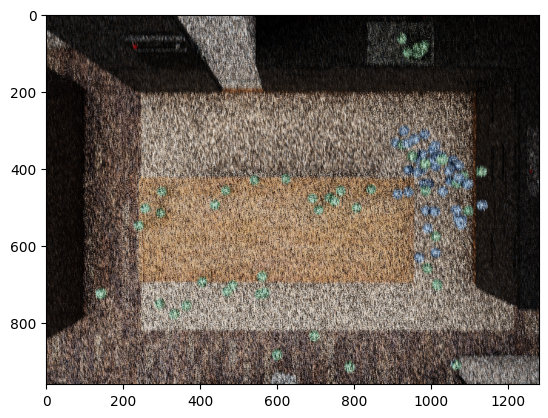

In [124]:
# import matplotlib.pyplot as plt
# for _ in range(10): og.sim.render()
# print(len(marker_list))
# viewer_camera_img = og.sim.viewer_camera.get_obs()[0]["rgb"][:, :, :3]
# plt.imshow(viewer_camera_img)
# plt.show()
# path = "/home/arpit/test_projects/mimicgen/paper_assets"
# plt.imsave(f'{path}/diversity_fig_tidy_table_D2.jpg', viewer_camera_img.numpy())

In [103]:
# import omnigibson.lazy as lazy
# from pxr import UsdGeom, Usd
# stage = lazy.omni.usd.get_context().get_stage()
# camera_path = og.sim.viewer_camera.prim_path
# camera_prim = stage.GetPrimAtPath(camera_path)
# camera = UsdGeom.Camera(camera_prim)
# # projection = camera.GetProjectionAttr().Get()
# camera.CreateProjectionAttr().Set(UsdGeom.Tokens.perspective)
# for _ in range(100): og.sim.render()

# og.sim.viewer_camera.horizontal_aperture = 60.0
# og.sim.viewer_camera.vertical_aperture
# og.sim.viewer_camera.focal_length